In [5]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm

import tidy3d as td
import tidy3d.web as web

import gdsfactory as gf
from DirectionalCoupler_GF import DirectionalCoupler

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler

WORKDIR   = Path().resolve()
REPO_ROOT = WORKDIR.parents[1]
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_directional_coupler_tidy3d"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler_tidy3d


In [ ]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1540e-9
LambdaStop     = 1560e-9

Height         = 800e-9
XLength        = 20e-6
YLength        = 10e-6

Index_core     = 1.97
Index_clad     = 1.445

SimulationTime = 500e-12
FrequencyPoints = 200

#------------------------------------------------------------
# MATERIALS
#------------------------------------------------------------
mat_core = td.Medium(permittivity=Index_core**2)
mat_clad = td.Medium(permittivity=Index_clad**2)


Core n: 1.95
Clad n: 1.45


Imported 1 structure(s)
  o1: center=(-66.00, -50.75) µm, orientation=180.0°
  o2: center=(66.00, -50.75) µm, orientation=0.0°
  o3: center=(-66.00, 50.75) µm, orientation=180.0°
  o4: center=(66.00, 50.75) µm, orientation=0.0°


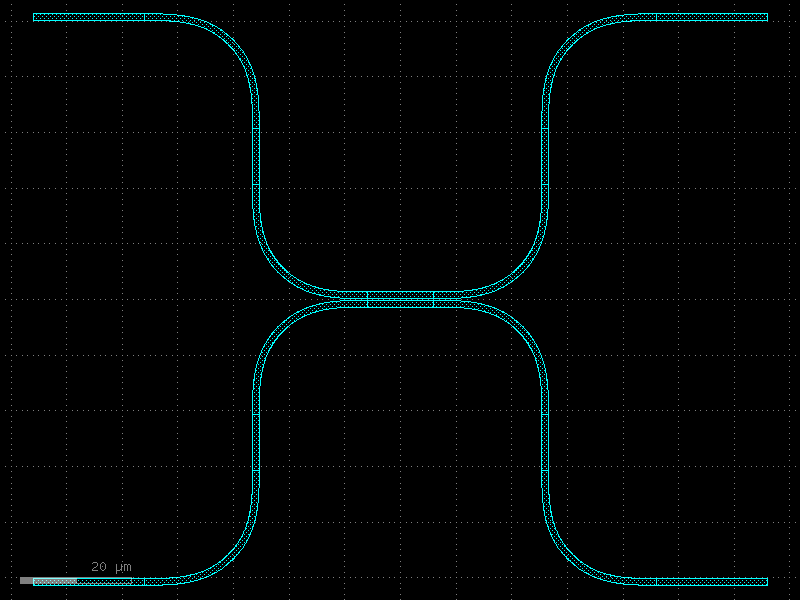

In [15]:
#------------------------------------------------------------
# SWEEP LISTS
#------------------------------------------------------------
Widths          = np.array([1200]) * 1e-9
ArcRadii        = np.array([20]) * 1e-6
CouplingLengths = np.array([12]) * 1e-6
Gaps            = np.array([300, 600]) * 1e-9
Eulers          = [1]

#------------------------------------------------------------
# GDS GENERATION (test single geometry)
#------------------------------------------------------------
gf.clear_cache()
dc = DirectionalCoupler(
    InLengthX=XLength * 1e6,
    LengthY=YLength * 1e6,
    CouplingLengthX=CouplingLengths[0] * 1e6,
    WgWidth=Widths[0] * 1e6,
    Radius=ArcRadii[0] * 1e6,
    Gap=Gaps[0] * 1e6,
    Euler=Eulers[0],
    Layer=(2, 0),
)

gds_path = str(WORKDIR / "DC_tidy3d_test.gds")
dc.write_gds(gds_path)
dc.plot()

#------------------------------------------------------------
# GDS → tidy3d structures
#------------------------------------------------------------
import gdstk

lib = gdstk.read_gds(gds_path)
top_cell = lib.top_level()[0]

geo = td.Geometry.from_gds(
    top_cell,
    gds_layer=2,
    gds_dtype=0,
    axis=2,
    slab_bounds=(0, Height * 1e6),  # m → µm
)

structs = [td.Structure(geometry=geo, medium=mat_core)]
print(f"Imported {len(structs)} structure(s)")

# Verify ports
for p in dc.ports:
    print(f"  {p.name}: center=({p.dcenter[0]:.2f}, {p.dcenter[1]:.2f}) µm, orientation={p.orientation}°")

In [ ]:
#------------------------------------------------------------
# HELPER FUNCTIONS
#------------------------------------------------------------
def start_section(name):
    tqdm.write(f"🏃 {name}...")
    return time.time()

def end_section(start):
    tqdm.write(f"✅ {time.time() - start:.1f}s")

#------------------------------------------------------------
# MULTI-DIMENSIONAL SWEEP
#------------------------------------------------------------
csv_path = data_save_dir / f"Kappa2_tidy3d_n{Index_core:.2f}_R{ArcRadii[0]*1e6:.0f}_W{Widths[0]*1e9:.0f}nm.csv"
all_results = []

if csv_path.exists():
    all_results = pd.read_csv(csv_path).to_dict('records')
    print(f"Loaded {len(all_results)} existing rows from {csv_path}")
else:
    all_results = []
    print("No existing CSV found — starting fresh.")

# Frequency range (tidy3d uses Hz and µm)
freq_center = td.C_0 / ((LambdaStart + LambdaStop) / 2 * 1e6)  # Hz, lambda in µm
fwidth      = td.C_0 / (LambdaStart * 1e6) - td.C_0 / (LambdaStop * 1e6)
freq_start  = td.C_0 / (LambdaStop * 1e6)
freq_stop   = td.C_0 / (LambdaStart * 1e6)

Height_um = Height * 1e6

for ArcRadius in tqdm(ArcRadii, desc="ArcRadius sweep", unit="R"):
    for Width in tqdm(Widths, desc="Width sweep", unit="W", leave=False):
        for Euler in tqdm(Eulers, desc="Euler sweep", leave=False):
            for CouplingLength in tqdm(CouplingLengths, desc="CL sweep", unit="CL", leave=False):
                for Gap in tqdm(Gaps, desc="Gap sweep", unit="gap", leave=False):

                    tag = f"R{ArcRadius*1e6:.0f}um_W{Width*1e9:.0f}nm_E{Euler}_CL{CouplingLength*1e6:.0f}um_gap{Gap*1e9:.0f}nm"
                    tqdm.write(f"--- {tag} ---")
                    t = start_section("Geometry Setup")

                    #------------------------------------------------------------
                    # GDS GENERATION
                    #------------------------------------------------------------
                    gf.clear_cache()
                    dc = DirectionalCoupler(
                        InLengthX=XLength * 1e6,
                        LengthY=YLength * 1e6,
                        CouplingLengthX=CouplingLength * 1e6,
                        WgWidth=Width * 1e6,
                        Radius=ArcRadius * 1e6,
                        Gap=Gap * 1e6,
                        Euler=Euler,
                        Layer=(2, 0),
                    )
                    gds_path = str(WORKDIR / "DC_tidy3d_sweep.gds")
                    dc.write_gds(gds_path)

                    #------------------------------------------------------------
                    # GDS → tidy3d structures
                    #------------------------------------------------------------
                    lib = gdstk.read_gds(gds_path)
                    top_cell = lib.top_level()[0]

                    geo = td.Geometry.from_gds(
                        top_cell,
                        gds_layer=2,
                        gds_dtype=0,
                        axis=2,
                        slab_bounds=(0, Height_um),
                    )
                    wg_struct = td.Structure(geometry=geo, medium=mat_core)

                    #------------------------------------------------------------
                    # BOUNDING BOX & PORTS (all in µm)
                    #------------------------------------------------------------
                    bbox = dc.bbox()
                    margin_um = 1.55 / 2

                    ports = {p.name: (p.dcenter[0], p.dcenter[1]) for p in dc.ports}  # already µm
                    offset_um = 4.0

                    x_min_um = bbox.left - margin_um
                    x_max_um = bbox.right + margin_um
                    y_min_um = bbox.bottom - margin_um
                    y_max_um = bbox.top + margin_um
                    z_min_um = -1.0
                    z_max_um = Height_um + 1.0

                    sim_center = (
                        (x_min_um + x_max_um) / 2,
                        (y_min_um + y_max_um) / 2,
                        (z_min_um + z_max_um) / 2,
                    )
                    sim_size = (
                        x_max_um - x_min_um,
                        y_max_um - y_min_um,
                        z_max_um - z_min_um,
                    )

                    src_x = x_min_um + offset_um
                    th_x  = x_max_um - offset_um
                    cr_x  = th_x

                    #------------------------------------------------------------
                    # SOURCE
                    #------------------------------------------------------------
                    source = td.ModeSource(
                        center=(src_x, ports["o3"][1], Height_um / 2),
                        size=(0, 3 * Width * 1e6, 4 * Height_um),
                        source_time=td.GaussianPulse(
                            freq0=freq_center,
                            fwidth=fwidth,
                        ),
                        direction="+",
                        mode_spec=td.ModeSpec(num_modes=1),
                        name="ModeSource",
                    )

                    #------------------------------------------------------------
                    # MONITORS
                    #------------------------------------------------------------
                    mon_through = td.ModeMonitor(
                        center=(th_x, ports["o4"][1], Height_um / 2),
                        size=(0, 3 * Width * 1e6, 4 * Height_um),
                        freqs=np.linspace(freq_start, freq_stop, FrequencyPoints),
                        mode_spec=td.ModeSpec(num_modes=1),
                        name="TH",
                    )

                    mon_cross = td.ModeMonitor(
                        center=(cr_x, ports["o2"][1], Height_um / 2),
                        size=(0, 3 * Width * 1e6, 4 * Height_um),
                        freqs=np.linspace(freq_start, freq_stop, FrequencyPoints),
                        mode_spec=td.ModeSpec(num_modes=1),
                        name="CR",
                    )

                    mon_field = td.FieldMonitor(
                        center=(0, 0, Height_um / 2),
                        size=(sim_size[0], sim_size[1], 0),
                        freqs=[freq_center],
                        name="Field Monitor",
                    )

                    #------------------------------------------------------------
                    # SIMULATION
                    #------------------------------------------------------------
                    sim = td.Simulation(
                        center=sim_center,
                        size=sim_size,
                        grid_spec=td.GridSpec.auto(
                            min_steps_per_wvl=20,
                            wavelength=1.55,
                        ),
                        structures=[wg_struct],
                        sources=[source],
                        monitors=[mon_through, mon_cross, mon_field],
                        run_time=SimulationTime,
                        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
                        medium=mat_clad,
                    )

                    end_section(t)

#                     #------------------------------------------------------------
#                     # RUN
#                     #------------------------------------------------------------
#                     t = start_section("Running solver")
#                     sim_data = web.run(sim, task_name=tag, path=str(data_save_dir / f"{tag}.hdf5"))
#                     end_section(t)

#                     #------------------------------------------------------------
#                     # EXTRACT RESULTS
#                     #------------------------------------------------------------
#                     try:
#                         th_amps = sim_data["TH"].amps.sel(mode_index=0, direction="+")
#                         cr_amps = sim_data["CR"].amps.sel(mode_index=0, direction="+")

#                         Tx_Through = np.abs(th_amps.values.flatten()) ** 2
#                         Tx_Cross   = np.abs(cr_amps.values.flatten()) ** 2
#                         Wavelength = td.C_0 / sim_data["TH"].freqs * 1e-6  # µm → m
#                     except Exception as e:
#                         tqdm.write(f"  ⚠ SKIPPED | {e}")
#                         continue

#                     Tx_total = Tx_Through + Tx_Cross

#                     idx_1550       = np.argmin(np.abs(Wavelength - 1550e-9))
#                     kappa_sq_1550  = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
#                     loss_dB_1550   = -10 * np.log10(Tx_total[idx_1550])

#                     tqdm.write(f"  κ²={kappa_sq_1550:.4f} | Loss={loss_dB_1550:.2f} dB")

#                     #------------------------------------------------------------
#                     # APPEND TO CSV
#                     #------------------------------------------------------------
#                     new_row = {
#                         "R"          : round(ArcRadius * 1e6, 3),
#                         "W"          : round(Width * 1e9, 3),
#                         "CL"         : round(CouplingLength * 1e6, 3),
#                         "G"          : round(Gap * 1e9, 3),
#                         "E"          : Euler,
#                         "Kappa_sq"   : kappa_sq_1550,
#                         "Loss"       : loss_dB_1550,
#                         "Tx_Cross"   : Tx_Cross[idx_1550],
#                         "Tx_Through" : Tx_Through[idx_1550],
#                     }

#                     key = ("R", "W", "E", "CL", "G")
#                     match = next((i for i, r in enumerate(all_results)
#                                   if all(r[k] == new_row[k] for k in key)), None)
#                     if match is not None:
#                         all_results[match] = new_row
#                         tqdm.write(f"  Updated existing row | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")
#                     else:
#                         all_results.append(new_row)
#                         tqdm.write(f"  New row added | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

#                     pd.DataFrame(all_results).to_csv(csv_path, index=False)

# #------------------------------------------------------------
# # MASTER CSV
# #------------------------------------------------------------
# df = pd.DataFrame(all_results)
# print(df)
# print(f"\nMaster CSV saved to {csv_path}")